In [18]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "Month": np.tile(range(1, 13), 3),
    "Year": np.repeat([2022, 2023, 2024], 12),
    "Advertising_Spend": np.random.randint(1000, 5000, 36),
    "Discount": np.random.randint(5, 30, 36)
}

df = pd.DataFrame(data)
df["Sales"] = (
    8 * df["Advertising_Spend"]
    - 300 * df["Discount"]
    + 1500 * df["Month"]
    + np.random.randint(0, 3000, 36)
)

df.to_csv("sales_data.csv", index=False)

df.head()

,Month,Year,Advertising_Spend,Discount,Sales
0,1,2022,4174,16,32047
1,2,2022,4507,29,31941
2,3,2022,1860,21,14101
3,4,2022,2294,14,22765
4,5,2022,2130,20,19669


In [2]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.info())
print(df.describe())

   Month  Year  Advertising_Spend  Discount  Sales
0      1  2022               4174        16  46531
1      2  2022               4507        29  21585
2      3  2022               1860        21  23943
3      4  2022               2294        14  43939
4      5  2022               2130        20  39457
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Month              36 non-null     int64
 1   Year               36 non-null     int64
 2   Advertising_Spend  36 non-null     int64
 3   Discount           36 non-null     int64
 4   Sales              36 non-null     int64
dtypes: int64(5)
memory usage: 1.5 KB
None
          Month         Year  Advertising_Spend   Discount         Sales
count  36.00000    36.000000          36.000000  36.000000     36.000000
mean    6.50000  2023.000000        2975.972222  17.944444  41843.638889
std     

In [19]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Month              36 non-null     int32
 1   Year               36 non-null     int32
 2   Advertising_Spend  36 non-null     int32
 3   Discount           36 non-null     int32
 4   Sales              36 non-null     int32
dtypes: int32(5)
memory usage: 848.0 bytes
None
          Month         Year  Advertising_Spend   Discount         Sales
count  36.00000    36.000000          36.000000  36.000000     36.000000
mean    6.50000  2023.000000        2975.972222  17.944444  29542.333333
std     3.50102     0.828079        1147.888882   6.654513   9602.249760
min     1.00000  2022.000000        1021.000000   6.000000  12021.000000
25%     3.75000  2022.000000        2121.250000  12.750000  21179.500000
50%     6.50000  2023.000000        2910.000000  19.000000  30220.000000
75%     9.25000  

In [21]:
print(df.isnull().sum())

Month                0
Year                 0
Advertising_Spend    0
Discount             0
Sales                0
dtype: int64


In [22]:
print(df.duplicated().sum())

0


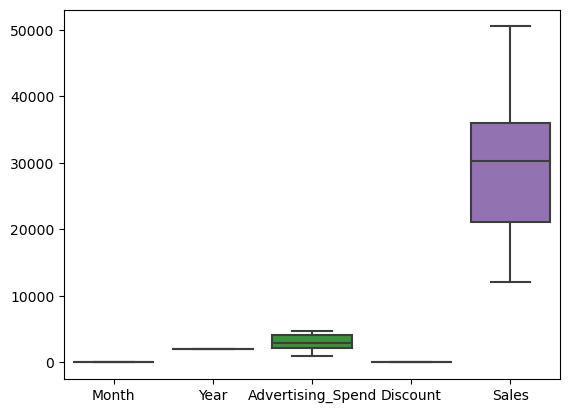

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

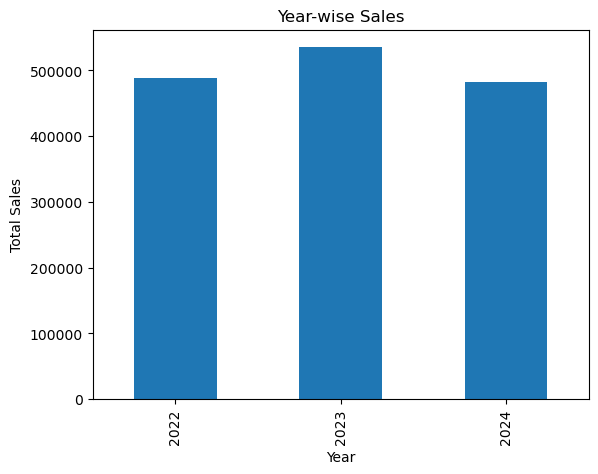

In [17]:
year_sales = df.groupby("Year")["Sales"].sum()

plt.figure()
year_sales.plot(kind="bar")
plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

In [24]:
X = df[["Advertising_Spend", "Discount", "Month", "Year"]]
y = df["Sales"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9933693969333425


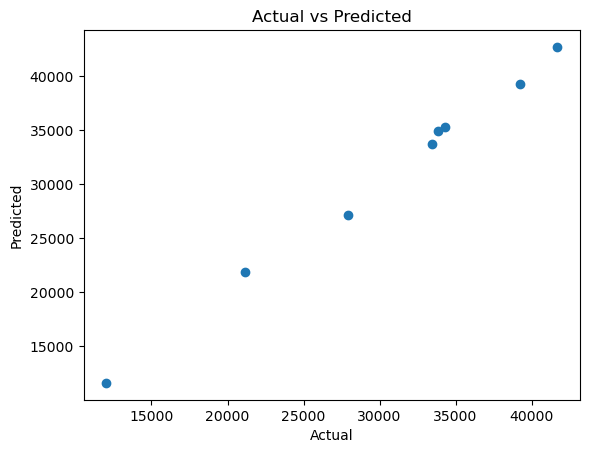

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

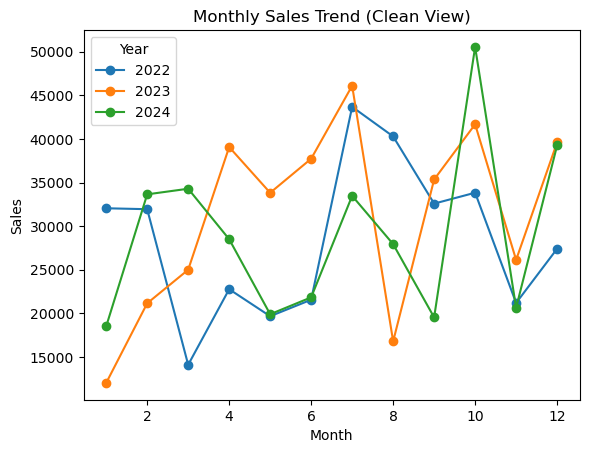

In [38]:
pivot = df.pivot(index="Month", columns="Year", values="Sales")

pivot.plot(marker='o')

plt.title("Monthly Sales Trend (Clean View)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

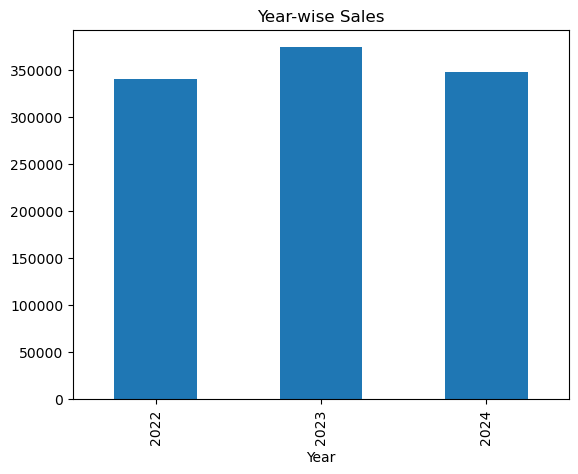

In [36]:
year_sales = df.groupby("Year")["Sales"].sum()

year_sales.plot(kind="bar")
plt.title("Year-wise Sales")
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print(df.head())

   Month  Year  Advertising_Spend  Discount  Sales
0      1  2022               4174        16  32047
1      2  2022               4507        29  31941
2      3  2022               1860        21  14101
3      4  2022               2294        14  22765
4      5  2022               2130        20  19669


In [8]:
df.head(15)

,Month,Year,Advertising_Spend,Discount,Sales
0,1,2022,4174,16,32047
1,2,2022,4507,29,31941
2,3,2022,1860,21,14101
3,4,2022,2294,14,22765
4,5,2022,2130,20,19669
5,6,2022,2095,19,21560
6,7,2022,4772,19,43678
7,8,2022,4092,23,40285
8,9,2022,2638,16,32581
9,10,2022,3169,27,33831


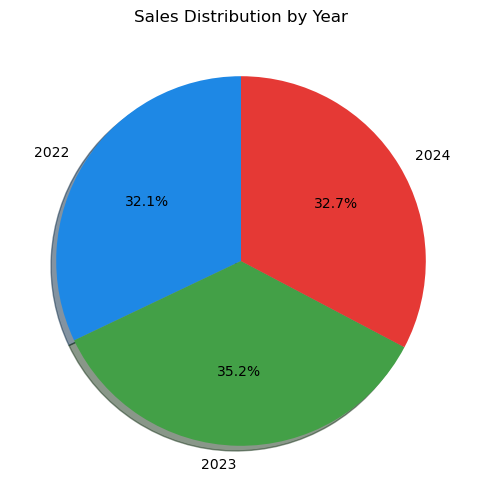

In [9]:
import matplotlib.pyplot as plt

# Group sales by year
year_sales = df.groupby("Year")["Sales"].sum()

# Define colors (attractive & professional)
colors = ["#1E88E5", "#43A047", "#E53935"]  # Blue, Green, Red

plt.figure(figsize=(6,6))

plt.pie(
    year_sales,
    labels=year_sales.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    shadow=True
)

plt.title("Sales Distribution by Year")

plt.show()

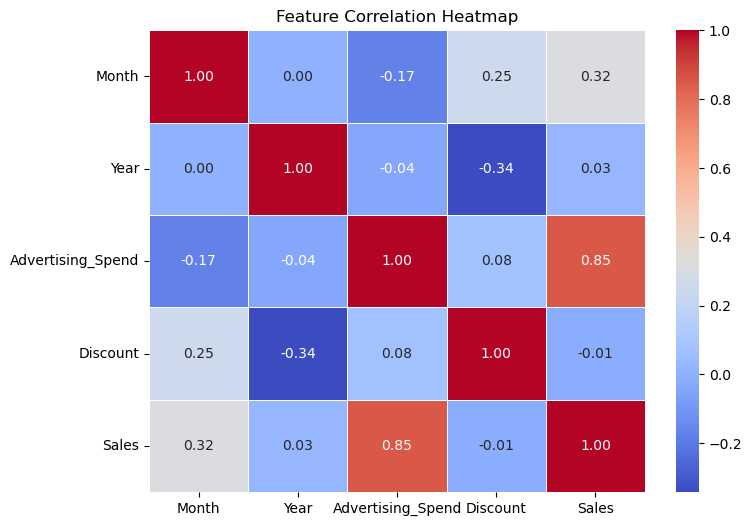

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr()

# Create heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,        # show values
    cmap="coolwarm",   # color theme
    fmt=".2f",         # 2 decimal points
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()